# Draft-Aware LoL Game Prediction — Research Notebook

Extension of the pre-draft model that incorporates **draft information** to predict
individual game outcomes. Designed for betting on single games within a series.

**Additional features over pre-draft model:**
- **Group L** – Champion meta: patch win rate of each pick (how strong is the draft?)
- **Group M** – Champion comfort: team's historical win rate with each picked champion
- **Group N** – Series context: game number, series score, must-win flag
- **First pick** advantage

**Pipeline:**
```
load_all → compute_elo → compute_draft_features → compute_features → build_dataset
```
Draft features are computed BEFORE compute_features() drops pick1-5 columns.
Pre-draft feature caches (team_df, elo_df) are shared with the pre-draft notebook.


---
## 0. Setup & Configuration

In [1]:
import warnings
import logging
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-7s  %(message)s',
    datefmt='%H:%M:%S',
)

ROOT = Path('.').resolve()
CACHE_DIR  = ROOT / 'cache'
OUTPUT_DIR = ROOT / 'outputs'
CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print('Root:', ROOT)

Root: /Users/danielzhao/MyMac/Masters Degree/Personal Projects/LoLPredictor/lol_model


In [2]:
# ── Key knobs ────────────────────────────────────────────────────────────────

USE_YEARS = list(range(2020, 2027))

TRAIN_DAYS        = 180
VAL_DAYS          = 14
STRIDE_DAYS       = 14
N_TUNE_ITER       = 20
TUNE_LAST_N_FOLDS = 30

# Cache prefix for draft-specific stages (shared: team_df, elo_df)
DRAFT_PFX = 'draft_'

# Force flags — set True to re-run a stage even if cache exists
FORCE_RELOAD        = False   # shared with pre-draft notebook
FORCE_ELO           = False   # shared with pre-draft notebook
FORCE_DRAFT_FEAT    = False   # draft feature engineering
FORCE_FEATURES      = False   # rolling features (post-draft)
FORCE_DATASET       = False   # dataset construction
FORCE_SPLIT         = False   # dev/holdout split
FORCE_CV            = False   # rolling CV
FORCE_TUNE          = False   # hyperparameter tuning
FORCE_ABLATION      = False   # ablation study

# Tuning cache — separate from pre-draft model
DRAFT_TUNE_CACHE = CACHE_DIR / 'draft_best_params.json'
OUTPUT_DRAFT_DIR = OUTPUT_DIR / 'draft'
OUTPUT_DRAFT_DIR.mkdir(exist_ok=True)

In [3]:
# ── Cache helpers ──────────────────────────────────────────────────────────────
# Pickle format: avoids ArrowDtype / arrow.py_extension_type issues across kernels.

def cache_save(df: pd.DataFrame, name: str) -> None:
    p = CACHE_DIR / f"{name}.pkl"
    df.to_pickle(p)
    print(f"  Cached {name} ({len(df):,} rows) → {p.name}")

def cache_load(name: str) -> pd.DataFrame | None:
    p = CACHE_DIR / f"{name}.pkl"
    if p.exists():
        df = pd.read_pickle(p)
        print(f"  Loaded {name} from cache ({len(df):,} rows)")
        return df
    return None

def folds_save(folds, name="folds"):
    with open(CACHE_DIR / f"{name}.pkl", "wb") as f:
        pickle.dump(folds, f)
    print(f"  Cached {len(folds)} folds")

def folds_load(name="folds"):
    p = CACHE_DIR / f"{name}.pkl"
    if p.exists():
        with open(p, "rb") as f:
            folds = pickle.load(f)
        print(f"  Loaded {len(folds)} folds from cache")
        return folds
    return None

---
## 1. Load Raw Data

Loads all yearly Oracle's Elixir CSVs, filters to team-level rows (`position == 'team'`), parses dates, and builds the opponent mapping (`opp_teamid`).  
No features are computed here — just raw data cleaning.

In [4]:
from pipeline.load_data import load_all

team_df = None if FORCE_RELOAD else cache_load('team_df')

if team_df is None:
    t0 = time.time()
    team_df, _ = load_all(use_years=USE_YEARS)
    print(f'  Loaded in {time.time()-t0:.1f}s')
    cache_save(team_df, 'team_df')

print(f'\nTeam rows:        {len(team_df):,}')
print(f'Unique matches:   {team_df["gameid"].nunique():,}')
print(f'Date range:       {team_df["date"].min().date()} – {team_df["date"].max().date()}')
print(f'Leagues:          {team_df["league"].nunique()}')
print(f'opp_teamid nulls: {team_df["opp_teamid"].isna().sum():,}')

  Loaded team_df from cache (136,798 rows)

Team rows:        136,798
Unique matches:   68,399
Date range:       2020-01-03 – 2026-04-03
Leagues:          106
opp_teamid nulls: 2,121


,date,league,teamname,side,result,opp_teamid
0,2020-01-03 07:33:26+00:00,KeSPA,Liiv SANDBOX,Blue,1,oe:team:ce499dea30cfce118f4fe85da0227e8
1,2020-01-03 07:33:26+00:00,KeSPA,T1,Red,0,oe:team:c75f1f337fc5867914749d438a4871d
2,2020-01-03 09:00:58+00:00,KeSPA,T1,Blue,0,oe:team:c75f1f337fc5867914749d438a4871d
3,2020-01-03 09:00:58+00:00,KeSPA,Liiv SANDBOX,Red,1,oe:team:ce499dea30cfce118f4fe85da0227e8
4,2020-01-03 10:05:17+00:00,KeSPA,T1,Blue,1,oe:team:c75f1f337fc5867914749d438a4871d
5,2020-01-03 10:05:17+00:00,KeSPA,Liiv SANDBOX,Red,0,oe:team:ce499dea30cfce118f4fe85da0227e8


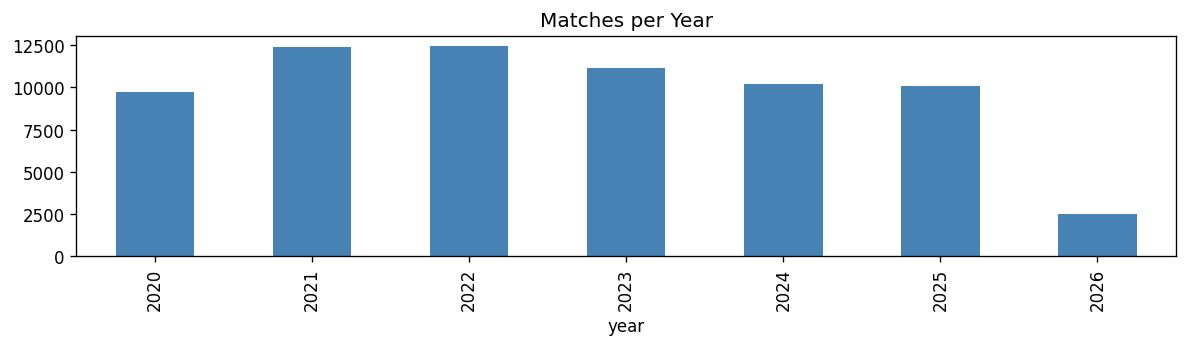

In [5]:
# Quick data overview
display(team_df[['date', 'league', 'teamname', 'side', 'result', 'opp_teamid']].head(6))

# Matches per year
team_df.assign(year=team_df['date'].dt.year).groupby('year')['gameid'].nunique() \
    .rename('matches').plot(kind='bar', figsize=(10, 3), title='Matches per Year', color='steelblue')
plt.tight_layout()
plt.show()

---
## 2. Elo Computation

Processes all matches in strict chronological order.  
**Leakage rule:** `elo_team` and `elo_opp` are recorded *before* the match result updates the ratings.  
K = 20, init = 1500.

In [6]:
from pipeline.elo import compute_elo

elo_df = None if FORCE_ELO else cache_load('elo_df')

if elo_df is None:
    t0 = time.time()
    elo_df = compute_elo(team_df)
    print(f'  Elo computed in {time.time()-t0:.1f}s')
    cache_save(elo_df, 'elo_df')

print(f'Elo range: [{elo_df["elo_team"].min():.0f}, {elo_df["elo_team"].max():.0f}]')

  Loaded elo_df from cache (136,798 rows)
Elo range: [1163, 1978]


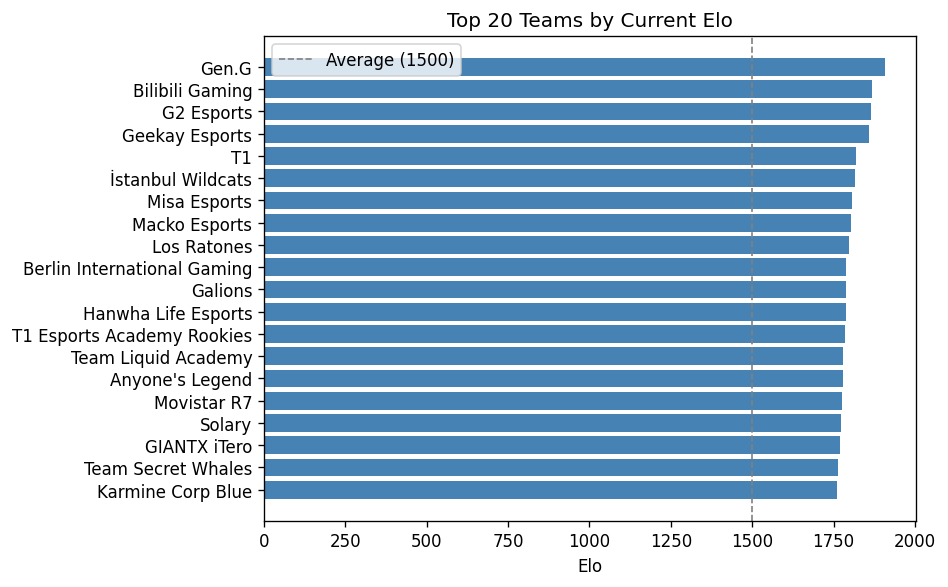

In [7]:
# Top 20 teams by current Elo (most recent entry per team)
latest_elo = (
    elo_df.sort_values('date')
    .groupby('teamname')[['elo_team', 'date']].last()
    .sort_values('elo_team', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(latest_elo.index[::-1], latest_elo['elo_team'][::-1], color='steelblue')
ax.axvline(1500, color='gray', ls='--', lw=1, label='Average (1500)')
ax.set_xlabel('Elo')
ax.set_title('Top 20 Teams by Current Elo')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Draft Feature Engineering

Computes champion and series features from the draft **before** rolling features
are added. Must run before `compute_features()` which drops pick1–5 columns.

| Group | Features | Signal |
|---|---|---|
| L | `champ_meta_mean/min/std` | Are your picks strong on this patch? |
| M | `champ_comfort_mean/min` | Does the team play well with these champions? |
| N | `series_game_num/score_diff/must_win` | Series state going into the game |
| — | `has_first_pick` | Draft order advantage |


In [8]:
from pipeline.draft_features import compute_draft_features

draft_elo_df = None if FORCE_DRAFT_FEAT else cache_load(f'{DRAFT_PFX}elo_df')

if draft_elo_df is None:
    t0 = time.time()
    draft_elo_df = compute_draft_features(elo_df)
    print(f'  Draft features computed in {time.time()-t0:.1f}s')
    cache_save(draft_elo_df, f'{DRAFT_PFX}elo_df')

draft_cols = [c for c in draft_elo_df.columns
              if c.startswith(('champ_', 'series_', 'has_first'))]
print(f'Draft feature columns added: {len(draft_cols)}')
print('Sample:', draft_cols)

# Correlation of new features with result
corrs = draft_elo_df[draft_cols + ['result']].corr()['result'].drop('result').abs()
print('\nCorrelation with result:')
display(corrs.sort_values(ascending=False).round(4).to_frame())

Draft feature engineering — 136,798 rows
  L  champion meta (patch win rates) ... done (4.0s)
  M  champion comfort (team rolling WR per champion) ... done (21.7s)
  N  series context ... done (33.9s)
     first pick ... done
Draft features complete — 9 new cols in 59.5s
  Draft features computed in 59.6s
  Cached draft_elo_df (136,798 rows) → draft_elo_df.pkl
Draft feature columns added: 9
Sample: ['champ_meta_mean', 'champ_meta_min', 'champ_meta_std', 'champ_comfort_mean', 'champ_comfort_min', 'series_game_num', 'series_score_diff', 'series_must_win', 'has_first_pick']

Correlation with result:


,result
champ_comfort_mean,0.1381
series_score_diff,0.1140
champ_comfort_min,0.1026
series_must_win,0.0863
has_first_pick,0.0520
champ_meta_mean,0.0399
champ_meta_min,0.0190
champ_meta_std,0.0034
series_game_num,0.0000


---
## 4. Rolling Feature Engineering

Runs on `draft_elo_df` (which already has champion/series features added).
Computes rolling win rates, Elo features, early-game stats, etc.
pick1-5 columns are dropped at the end of this step (via `RAW_INPUT_COLS`).


In [9]:
from pipeline.features import compute_features, get_feature_cols

feat_df = None if FORCE_FEATURES else cache_load(f'{DRAFT_PFX}feat_df')

if feat_df is None:
    t0 = time.time()
    feat_df = compute_features(draft_elo_df)   # uses draft_elo_df, not plain elo_df
    print(f'  Features computed in {time.time()-t0:.1f}s')
    cache_save(feat_df, f'{DRAFT_PFX}feat_df')

base_fcols = get_feature_cols(feat_df)
draft_fcols = [c for c in base_fcols if c.startswith(('champ_', 'series_', 'has_first'))]
print(f'Total feature columns: {len(base_fcols)}  (of which {len(draft_fcols)} are draft features)')
print('Draft features in feat_df:', draft_fcols)

Feature engineering — 136,798 rows
  B  recent form ... done (1.1s)
  C  early-game (means + thresholds) ... done (3.5s)
  D  conversion/closing ... done (1.1s)
  E  objective control ... done (1.5s)
  F  style ... done (0.6s)
  G  side history ... done (0.5s)
  H  patch adaptation ... done (7.7s)
  J  schedule/context ... done (1.8s)
  K  interactions ... done (0.0s)
Feature engineering complete — 103 feature cols in 17.8s


20:01:50  INFO     Feature engineering complete. 103 engineered feature cols.


  Features computed in 17.9s
  Cached draft_feat_df (136,798 rows) → draft_feat_df.pkl
Total feature columns: 103  (of which 9 are draft features)
Draft features in feat_df: ['champ_meta_mean', 'champ_meta_min', 'champ_meta_std', 'champ_comfort_mean', 'champ_comfort_min', 'series_game_num', 'series_score_diff', 'series_must_win', 'has_first_pick']


In [10]:
# Feature completeness: fraction of non-null values per feature
completeness = feat_df[base_fcols].notna().mean().sort_values()
incomplete = completeness[completeness < 0.95]
if len(incomplete):
    print(f'{len(incomplete)} features with <95% completeness:')
    display(incomplete.to_frame('fill_rate').tail(20))
else:
    print('All features ≥95% complete.')

All features ≥95% complete.


---
## 5. Dataset Construction

For each row (team A in game G):
- Team features + **draft features** for team A
- Opponent features + **draft features** for team B (as `opp_*` columns)
- Differences `diff_* = team - opp` for all numeric features

Key draft diff features:
- `diff_champ_meta_mean` = team draft strength minus opponent draft strength
- `diff_champ_comfort_mean` = team comfort advantage
- `series_score_diff` = team wins minus losses (not diffed — it's already relative)


In [11]:
from pipeline.dataset import build_dataset, get_model_cols

ds_df = None if FORCE_DATASET else cache_load(f'{DRAFT_PFX}dataset_df')

if ds_df is None:
    t0 = time.time()
    ds_df = build_dataset(feat_df)
    print(f'  Dataset built in {time.time()-t0:.1f}s')
    cache_save(ds_df, f'{DRAFT_PFX}dataset_df')

num_cols, cat_cols = get_model_cols(ds_df)
draft_num = [c for c in num_cols if any(c.startswith(p) for p in
             ('champ_', 'series_', 'has_first', 'opp_champ', 'opp_series',
              'diff_champ', 'diff_series'))]
print(f'Dataset shape:        {ds_df.shape}')
print(f'Total numeric feats:  {len(num_cols)}')
print(f'Draft numeric feats:  {len(draft_num)}')
print(f'Draft feature names:  {draft_num}')
print(f'Categorical:          {cat_cols}')
print(f'Target win rate:      {ds_df["result"].mean():.4f}')

20:01:50  INFO     Merging opponent features for 103 feature columns
20:01:50  INFO     Dropped 5 symmetric opp_ columns
20:01:50  INFO     Added 95 diff_ columns
20:01:50  INFO     Dataset built: 137488 rows, 296 feature cols (team + opp + diff)


  Dataset built in 0.1s
  Cached draft_dataset_df (137,488 rows) → draft_dataset_df.pkl
Dataset shape:        (137488, 309)
Total numeric feats:  296
Draft numeric feats:  23
Draft feature names:  ['champ_meta_mean', 'champ_meta_min', 'champ_meta_std', 'champ_comfort_mean', 'champ_comfort_min', 'series_game_num', 'series_score_diff', 'series_must_win', 'has_first_pick', 'opp_champ_meta_mean', 'opp_champ_meta_min', 'opp_champ_meta_std', 'opp_champ_comfort_mean', 'opp_champ_comfort_min', 'opp_series_score_diff', 'opp_series_must_win', 'diff_champ_meta_mean', 'diff_champ_meta_min', 'diff_champ_meta_std', 'diff_champ_comfort_mean', 'diff_champ_comfort_min', 'diff_series_game_num', 'diff_series_must_win']
Categorical:          ['league', 'split', 'side', 'patch']
Target win rate:      0.4999


In [12]:
# Quick leakage sanity check
forbidden_patterns = ['champion', 'pick1', 'ban1', 'firstPick', 'elo_overperf']
leaked = [c for c in num_cols if any(p in c for p in forbidden_patterns)]
print('Forbidden cols in feature matrix:', leaked if leaked else '✓ NONE – clean')

# Check elo_overperf not included directly
direct_overperf = [c for c in num_cols if c.replace('opp_','').replace('diff_','') == 'elo_overperf']
print('Direct elo_overperf in features:', direct_overperf if direct_overperf else '✓ NONE – clean (only rolled versions allowed)')

Forbidden cols in feature matrix: ✓ NONE – clean
Direct elo_overperf in features: ✓ NONE – clean (only rolled versions allowed)


---
## 6. Train / Validation / Holdout Split

Same time-based split as pre-draft model.
Uses draft-prefixed cache files to avoid conflicts.


In [13]:
from pipeline.validation import dev_holdout_split, rolling_folds, check_fold_leakage, describe_folds

dev_df  = None if FORCE_SPLIT else cache_load(f'{DRAFT_PFX}dev_df')
hold_df = None if FORCE_SPLIT else cache_load(f'{DRAFT_PFX}hold_df')
folds   = None if FORCE_SPLIT else folds_load(f'{DRAFT_PFX}folds')

if dev_df is None or hold_df is None or folds is None:
    dev_df, hold_df = dev_holdout_split(ds_df)
    folds = rolling_folds(dev_df, TRAIN_DAYS, VAL_DAYS, STRIDE_DAYS)
    check_fold_leakage(dev_df, folds)
    cache_save(dev_df,  f'{DRAFT_PFX}dev_df')
    cache_save(hold_df, f'{DRAFT_PFX}hold_df')
    folds_save(folds,   f'{DRAFT_PFX}folds')

print(f'Dev rows:     {len(dev_df):,}  ({dev_df["date"].min().date()} – {dev_df["date"].max().date()})')
print(f'Holdout rows: {len(hold_df):,}  ({hold_df["date"].min().date()} – {hold_df["date"].max().date()})')
print(f'Folds:        {len(folds)}')
print(f'Num features: {len(num_cols)} numeric, {len(cat_cols)} categorical')

20:01:50  INFO     Split: dev=109710 rows (54719 matches) up to 2024-09-18 | holdout=27778 rows (13680 matches)
20:01:50  INFO     Generated 109 rolling folds (train=180d, val=14d, stride=14d)
20:01:50  INFO     Val fold sizes: min=10, median=700, max=2112
20:01:51  INFO     Fold leakage check passed for all 109 folds


  Cached draft_dev_df (109,710 rows) → draft_dev_df.pkl
  Cached draft_hold_df (27,778 rows) → draft_hold_df.pkl
  Cached 109 folds
Dev rows:     109,710  (2020-01-03 – 2024-09-18)
Holdout rows: 27,778  (2024-09-18 – 2026-04-03)
Folds:        109
Num features: 296 numeric, 4 categorical


,fold,train_start,train_end,val_start,val_end,train_rows,val_rows,train_games,val_games
99,99,2023-11-03,2024-05-01,2024-05-01,2024-05-15,8908,402,4452,198
100,100,2023-11-17,2024-05-15,2024-05-15,2024-05-29,8858,648,4424,324
101,101,2023-12-25,2024-05-29,2024-05-29,2024-06-12,9394,1318,4692,659
102,102,2023-12-25,2024-06-12,2024-06-12,2024-06-26,10712,1682,5351,841
103,103,2023-12-31,2024-06-26,2024-06-26,2024-07-10,12330,1250,6160,625
104,104,2024-01-12,2024-07-10,2024-07-10,2024-07-24,13444,1356,6719,678
105,105,2024-01-26,2024-07-24,2024-07-24,2024-08-06,14076,1268,7035,634
106,106,2024-02-09,2024-08-06,2024-08-07,2024-08-20,14042,936,7018,468
107,107,2024-02-23,2024-08-20,2024-08-21,2024-09-04,13880,508,6937,254
108,108,2024-03-08,2024-09-04,2024-09-04,2024-09-17,12822,506,6408,251


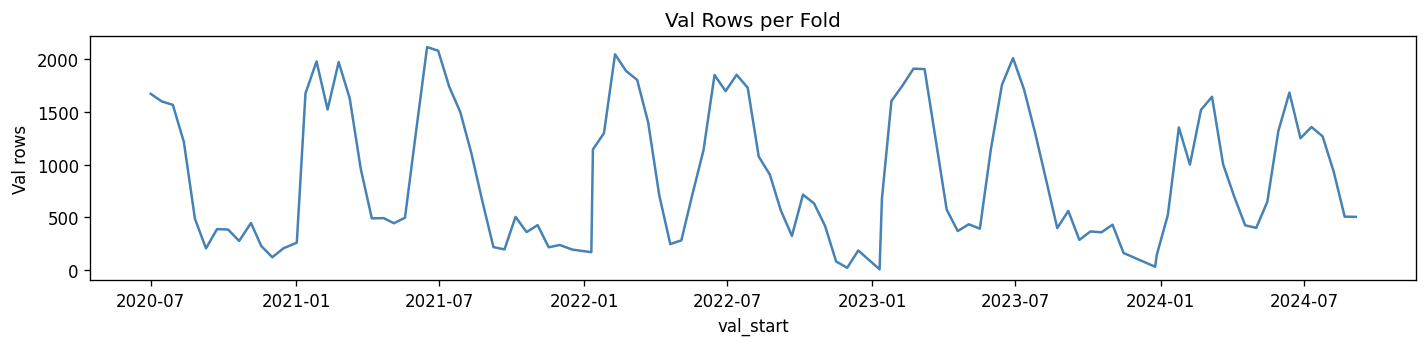

In [14]:
# Fold overview
fold_desc = describe_folds(dev_df, folds)
display(fold_desc.tail(10))

# Val size over time
fold_desc.plot(
    x='val_start', y='val_rows', figsize=(12, 3),
    title='Val Rows per Fold', legend=False, color='steelblue'
)
plt.ylabel('Val rows')
plt.tight_layout()
plt.show()

---
## 7. Rolling Cross-Validation

Same rolling CV setup as pre-draft model.
Results written to `outputs/draft/cv_results.csv`.


In [15]:
from pipeline.models import run_cv, summarise_cv, MODEL_NAMES, BASELINE_METRICS
from pipeline.tuning import load_best_params

cv_path = OUTPUT_DRAFT_DIR / 'cv_results.csv'
cv_df = None

if not FORCE_CV and cv_path.exists():
    cv_df = pd.read_csv(cv_path)
    print(f'Loaded CV results from {cv_path.name} ({len(cv_df)} rows)')

if cv_df is None:
    best_params = load_best_params(DRAFT_TUNE_CACHE) or {m: {} for m in MODEL_NAMES}
    t0 = time.time()
    cv_df = run_cv(dev_df, folds, num_cols, cat_cols, best_params)
    print(f'  CV complete in {time.time()-t0:.1f}s')
    cv_df.to_csv(cv_path, index=False)

num_cols, cat_cols = get_model_cols(dev_df)

Rolling CV — 109 folds × 5 models
  fold   1/109  [lasso=0.6110  ridge=0.6103  elasticnet=0.6111  logistic=0.6103  xgboost=0.6091]  elapsed=3s  eta=295s


20:01:54  INFO     CV progress: fold 1 / 109


  fold   2/109  [lasso=0.6047  ridge=0.6044  elasticnet=0.6052  logistic=0.6044  xgboost=0.6055]  elapsed=7s  eta=377s


20:01:58  INFO     CV progress: fold 2 / 109


  fold   3/109  [lasso=0.6036  ridge=0.6027  elasticnet=0.6047  logistic=0.6027  xgboost=0.6022]  elapsed=11s  eta=394s


...

  fold 108/109  [lasso=0.6514  ridge=0.6523  elasticnet=0.6515  logistic=0.6523  xgboost=0.6630]  elapsed=358s  eta=3s


20:07:50  INFO     CV progress: fold 108 / 109


  fold 109/109  [lasso=0.6818  ridge=0.6789  elasticnet=0.6817  logistic=0.6789  xgboost=0.6861]  elapsed=362s  eta=0s


20:07:54  INFO     CV progress: fold 109 / 109


CV complete in 362s
  CV complete in 362.2s


In [16]:
# CV Summary table
summary = summarise_cv(cv_df)
print('CV Summary (mean ± std across folds):')
print()
display(summary)
print()
print('Baseline (predict 0.5 always):', BASELINE_METRICS)

CV Summary (mean ± std across folds):



log_loss             brier          accuracy         
               mean      std     mean      std     mean      std
model                                                           
elasticnet  0.65002  0.04344  0.22893  0.01862  0.61863  0.05270
lasso_lr    0.65006  0.04393  0.22894  0.01879  0.61861  0.05335
logistic    0.64981  0.04235  0.22882  0.01828  0.62016  0.04799
ridge_lr    0.64940  0.04193  0.22864  0.01807  0.62014  0.04837
xgboost     0.64804  0.03767  0.22853  0.01701  0.62122  0.04481


Baseline (predict 0.5 always): {'log_loss': 0.6931, 'brier': 0.25, 'accuracy': 0.5}


20:07:54  INFO     Saved /Users/danielzhao/MyMac/Masters Degree/Personal Projects/LoLPredictor/lol_model/outputs/cv_log_loss.png


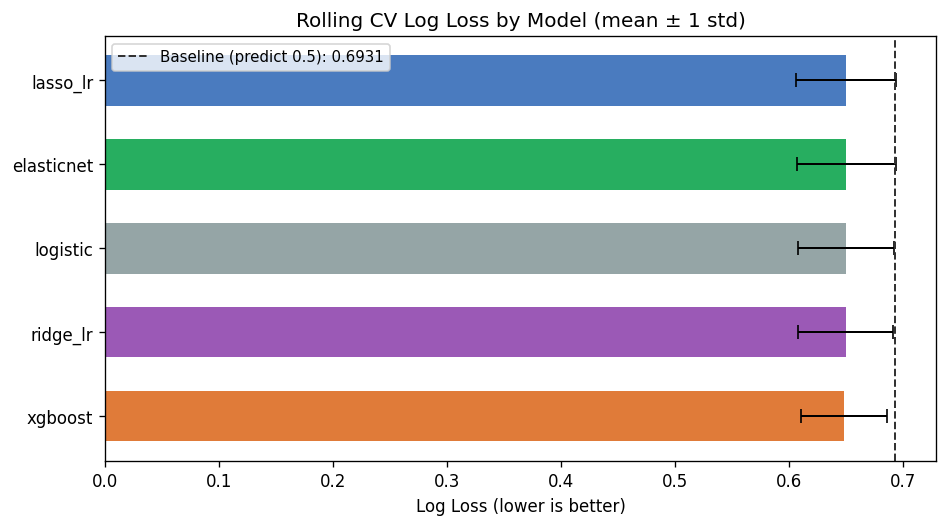

In [17]:
# CV Log-loss bar chart
from pipeline.evaluation import plot_cv_summary, plot_cv_metric_over_time
fig = plot_cv_summary(cv_df, save=True)
plt.show()

---
## 8. Hyperparameter Tuning

Same random search as pre-draft model.
Results cached to `cache/draft_best_params.json` (separate from pre-draft).


In [18]:
import json
from pipeline.tuning import tune_all_models, load_best_params

best_params = tune_all_models(
    dev_df, folds, num_cols, cat_cols,
    n_iter=N_TUNE_ITER,
    last_n_folds=TUNE_LAST_N_FOLDS,
    force_retune=FORCE_TUNE,
    cache_path=DRAFT_TUNE_CACHE,
)

print('\nBest hyperparameters:')
print(json.dumps(best_params, indent=2))

20:07:54  INFO     Tuning on 30 folds (last 30 of 109 total)
20:07:54  INFO     Tuning lasso_lr (20 iterations × 30 folds) ...



[lasso_lr] tuning 20 combos × 30 folds ...
  combo   1/20  loss=0.63880 *
  combo   2/20  loss=0.69315
  combo   3/20  loss=0.69315
  combo   4/20  loss=0.63664 *
  combo   5/20  loss=0.64686
  combo   6/20  loss=0.64146
  combo   7/20  loss=0.69315
  combo   8/20  loss=0.64085
  combo   9/20  loss=0.69315
  combo  10/20  loss=0.63437 *
  combo  11/20  loss=0.63980
  combo  12/20  loss=0.63487
  combo  13/20  loss=0.69315
  combo  14/20  loss=0.63686
  combo  15/20  loss=0.63293 *
  combo  16/20  loss=0.63931
  combo  17/20  loss=0.63538
  combo  18/20  loss=0.63312
  combo  19/20  loss=0.68906
  combo  20/20  loss=0.66597


20:10:58  INFO     lasso_lr         best log_loss=0.63293  params={'C': 0.015}


[lasso_lr] done — best log_loss=0.63293  params={'C': 0.015}


20:10:58  INFO     Tuning ridge_lr (20 iterations × 30 folds) ...


...


[xgboost] tuning 20 combos × 30 folds ...
  combo   1/20  loss=0.63633 *
  combo   2/20  loss=0.64175
  combo   3/20  loss=0.63710
  combo   4/20  loss=0.65364
  combo   5/20  loss=0.63534 *
  combo   6/20  loss=0.63833
  combo   7/20  loss=0.64311
  combo   8/20  loss=0.64943
  combo   9/20  loss=0.63799
  combo  10/20  loss=0.67042
  combo  11/20  loss=0.63933
  combo  12/20  loss=0.66340
  combo  13/20  loss=0.63955
  combo  14/20  loss=0.65154
  combo  15/20  loss=0.63636
  combo  16/20  loss=0.63869
  combo  17/20  loss=0.69239
  combo  18/20  loss=0.64442
  combo  19/20  loss=0.66286
  combo  20/20  loss=0.63437 *


20:30:22  INFO     xgboost          best log_loss=0.63437  params={'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 1.0, 'reg_lambda': 1, 'min_child_weight': 10}


[xgboost] done — best log_loss=0.63437  params={'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 1.0, 'reg_lambda': 1, 'min_child_weight': 10}


20:30:22  INFO     Saved best params to /Users/danielzhao/MyMac/Masters Degree/Personal Projects/LoLPredictor/lol_model/cache/draft_best_params.json



Best hyperparameters:
{
  "lasso_lr": {
    "C": 0.015
  },
  "ridge_lr": {
    "C": 0.0002
  },
  "elasticnet": {
    "C": 0.01,
    "l1_ratio": 0.6
  },
  "logistic": {},
  "xgboost": {
    "n_estimators": 500,
    "max_depth": 5,
    "learning_rate": 0.01,
    "subsample": 0.7,
    "colsample_bytree": 1.0,
    "reg_lambda": 1,
    "min_child_weight": 10
  }
}


---
## 8. Re-run CV with Tuned Parameters

Optional: re-run CV with best params to see the improvement. Skip if you already ran Stage 6 with tuned params loaded.

In [19]:
# Re-run CV on last 20 folds only (fast) with tuned params
print('CV on last 20 folds with tuned params...')
tuned_cv_df = run_cv(dev_df, folds[-20:], num_cols, cat_cols, best_params)

print('\nTuned CV Summary (last 20 folds):')
display(summarise_cv(tuned_cv_df))

CV on last 20 folds with tuned params...
Rolling CV — 20 folds × 5 models
  fold   1/20  [lasso=0.6904  ridge=0.6828  elasticnet=0.6969  logistic=0.7116  xgboost=0.6911]  elapsed=2s  eta=46s


20:30:25  INFO     CV progress: fold 1 / 20


  fold   2/20  [lasso=0.6370  ridge=0.6329  elasticnet=0.6367  logistic=0.6440  xgboost=0.6340]  elapsed=5s  eta=43s


20:30:27  INFO     CV progress: fold 2 / 20


  fold   3/20  [lasso=0.6467  ridge=0.6478  elasticnet=0.6471  logistic=0.6517  xgboost=0.6568]  elapsed=7s  eta=38s


...

20:31:07  INFO     CV progress: fold 19 / 20


  fold  20/20  [lasso=0.6715  ridge=0.6689  elasticnet=0.6723  logistic=0.6789  xgboost=0.6794]  elapsed=48s  eta=0s


20:31:10  INFO     CV progress: fold 20 / 20


CV complete in 48s

Tuned CV Summary (last 20 folds):


log_loss             brier          accuracy         
               mean      std     mean      std     mean      std
model                                                           
elasticnet  0.63130  0.03312  0.22109  0.01468  0.63775  0.04355
lasso_lr    0.63104  0.03239  0.22096  0.01437  0.63752  0.04422
logistic    0.63712  0.03554  0.22355  0.01556  0.63608  0.03901
ridge_lr    0.63066  0.03120  0.22088  0.01390  0.63793  0.03705
xgboost     0.63304  0.03424  0.22203  0.01504  0.63724  0.03483

---
## 9. Final Holdout Evaluation

Trains on full dev set, evaluates on holdout (2024–2026 data).
Compare holdout log-loss here vs pre-draft model (~0.630) to quantify
how much draft information improves prediction.


In [20]:
from pipeline.evaluation import (
    evaluate_on_holdout, holdout_summary_df,
    plot_calibration, plot_feature_importance,
)

holdout_results = evaluate_on_holdout(
    dev_df, hold_df, num_cols, cat_cols, best_params
)

summary_df = holdout_summary_df(holdout_results)
summary_df.to_csv(OUTPUT_DRAFT_DIR / 'holdout_results.csv')

print('Holdout Results (draft model):')
display(summary_df)
print()
print('Pre-draft model reference: logloss ≈ 0.6298')

20:31:13  INFO     Holdout lasso_lr         log_loss=0.62936  brier=0.22010  acc=0.6373
20:31:13  INFO     Holdout ridge_lr         log_loss=0.63015  brier=0.22042  acc=0.6389
20:31:26  INFO     Holdout elasticnet       log_loss=0.62932  brier=0.22009  acc=0.6372
20:31:26  INFO     Holdout logistic         log_loss=0.62962  brier=0.22020  acc=0.6370
20:31:35  INFO     Holdout xgboost          log_loss=0.62947  brier=0.22018  acc=0.6355


Holdout Results (draft model):


,log_loss,brier,accuracy
model,,,
lasso_lr,0.62936,0.22010,0.63727
ridge_lr,0.63015,0.22042,0.63885
elasticnet,0.62932,0.22009,0.63723
logistic,0.62962,0.22020,0.63698
xgboost,0.62947,0.22018,0.63550
baseline,0.69310,0.25000,0.50000



Pre-draft model reference: logloss ≈ 0.6298


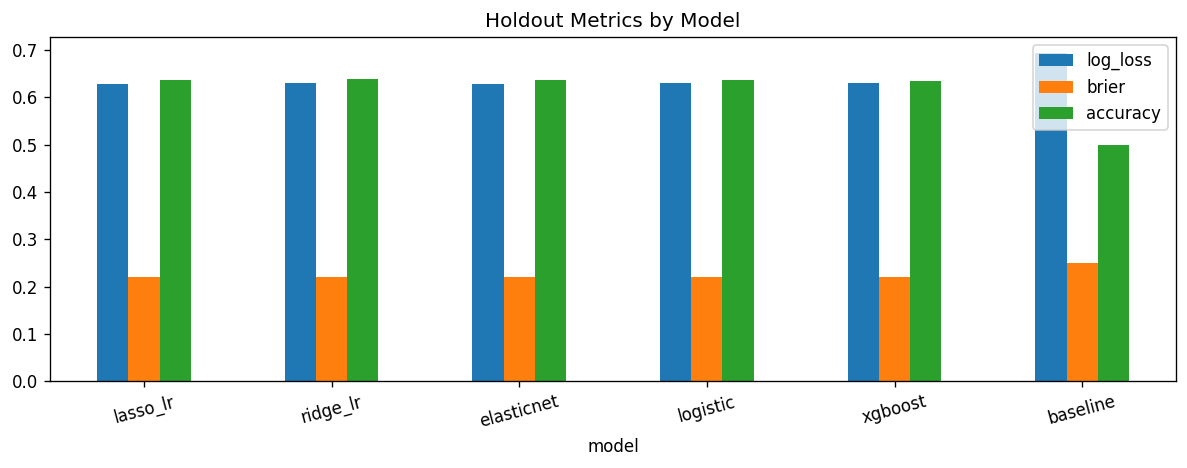

In [21]:
# Holdout bar chart
ax = summary_df[['log_loss', 'brier', 'accuracy']].plot(
    kind='bar', figsize=(10, 4), title='Holdout Metrics by Model',
    subplots=False, rot=15
)
plt.tight_layout()
plt.show()

20:31:35  INFO     Saved /Users/danielzhao/MyMac/Masters Degree/Personal Projects/LoLPredictor/lol_model/outputs/calibration.png


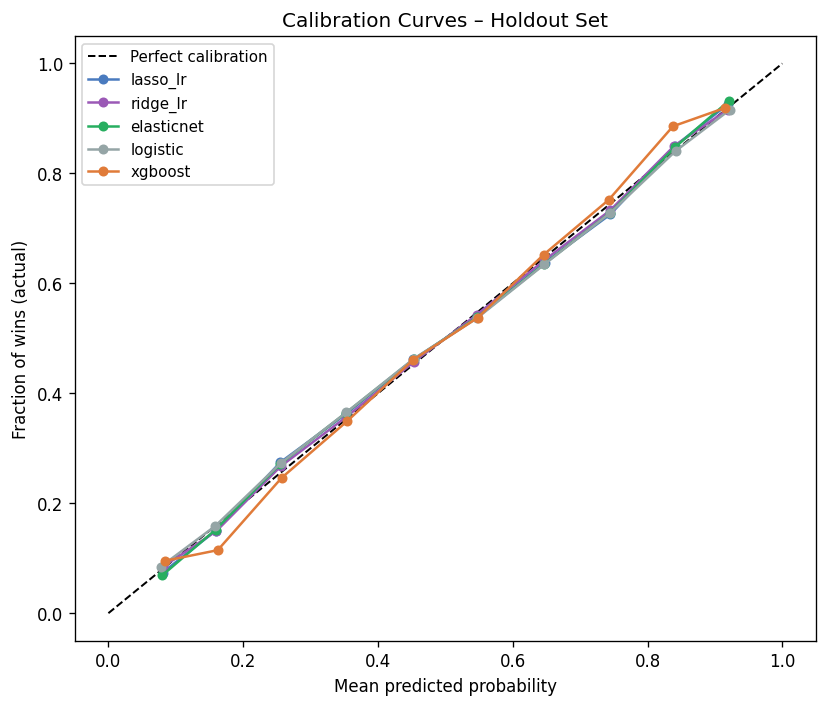

In [22]:
# Calibration curves
fig = plot_calibration(holdout_results, save=True)
plt.show()

---
## 10. Feature Importance & Ablation

Ablation quantifies how much each group contributes.
Draft groups are compared against the pre-draft baseline.


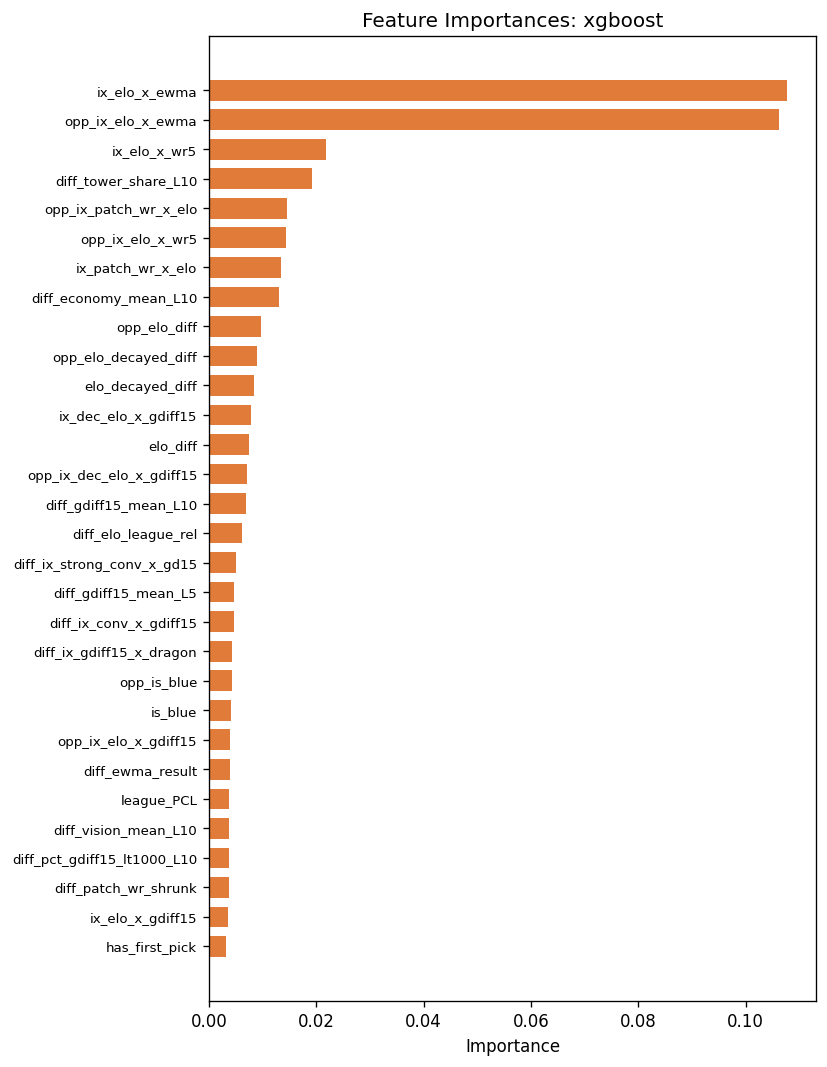

In [23]:
# XGBoost feature importances
from pipeline.evaluation import plot_feature_importance
fig = plot_feature_importance(
    dev_df, num_cols, cat_cols, best_params,
    top_n=30, save=False,
)
fig.savefig(OUTPUT_DRAFT_DIR / 'feature_importance.png', dpi=150)
plt.show()

In [24]:
# Lasso logistic regression: non-zero coefficients (implicit feature selection)
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from pipeline.models import MODEL_REGISTRY, make_preprocessor

pre = make_preprocessor(num_cols, cat_cols)
X_dev = pre.fit_transform(dev_df[num_cols + cat_cols])
y_dev = dev_df['result'].values

estimator, _ = MODEL_REGISTRY['lasso_lr']
lasso = clone(estimator)
params = best_params.get('lasso_lr', {})
if params:
    lasso.set_params(**params)
lasso.fit(X_dev, y_dev)

# Get feature names
try:
    num_names = list(pre.named_transformers_['num'].get_feature_names_out(num_cols))
    cat_names = list(pre.named_transformers_['cat'].get_feature_names_out())
    feature_names = num_names + cat_names
except (KeyError, AttributeError):
    feature_names = [f'f{i}' for i in range(X_dev.shape[1])]

coef = lasso.coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
coef_df = coef_df[coef_df['coef'] != 0].sort_values('coef', key=abs, ascending=False)

print(f'Lasso non-zero coefficients: {len(coef_df)} / {len(feature_names)}')
display(coef_df.head(30))

Lasso non-zero coefficients: 72 / 532


,feature,coef
267,diff_tower_share_L10,0.281123
273,diff_economy_mean_L10,0.202216
292,diff_ix_opp_elo_x_wr10,-0.185070
275,diff_gamelength_mean_L10,-0.134871
220,diff_avg_opp_elo_L10,0.127485
280,diff_patch_wr_shrunk,0.114458
109,opp_elo_decayed_diff,-0.110526
271,diff_pace_mean_L10,-0.108235
79,is_blue,0.100695
272,diff_vision_mean_L10,0.100364


In [25]:
# ── Draft ablation study ────────────────────────────────────────────────────
# Compares pre-draft feature groups + each draft group.
# Uses ridge_lr with tuned params for speed + interpretability.
from pipeline.evaluation import run_ablation, ABLATION_GROUPS, ABLATION_SETS
from pipeline.models import MODEL_NAMES

# Extend ablation groups with draft-specific groups
DRAFT_ABLATION_GROUPS = {
    **ABLATION_GROUPS,
    'L_champ_meta':    ['champ_meta_'],
    'M_champ_comfort': ['champ_comfort_'],
    'N_series':        ['series_', 'has_first_pick'],
}

DRAFT_ABLATION_SETS = {
    # Pre-draft baseline (reproduces pre-draft model performance)
    'PreDraft_Full':          list(ABLATION_GROUPS.keys()),
    # Add each draft group individually
    'PreDraft+ChampMeta':     list(ABLATION_GROUPS.keys()) + ['L_champ_meta'],
    'PreDraft+ChampComfort':  list(ABLATION_GROUPS.keys()) + ['M_champ_comfort'],
    'PreDraft+Series':        list(ABLATION_GROUPS.keys()) + ['N_series'],
    # All draft groups combined
    'Draft_Full':             list(ABLATION_GROUPS.keys()) + ['L_champ_meta', 'M_champ_comfort', 'N_series'],
}

abl_path = OUTPUT_DRAFT_DIR / 'ablation_results.csv'
abl_df = None

if abl_path.exists() and not FORCE_ABLATION:
    abl_df = pd.read_csv(abl_path)
    print(f'Loaded from {abl_path.name}')

if abl_df is None:
    from pipeline.evaluation import _cols_in_group, train_eval_fold, make_preprocessor
    import numpy as np
    import time as _time
    model_name = 'ridge_lr'
    params = best_params.get(model_name, {})
    tune_folds = folds[-30:] if len(folds) > 30 else folds
    results = []
    print(f'Draft ablation — {len(DRAFT_ABLATION_SETS)} sets × {len(tune_folds)} folds ({model_name})')
    print(f'  Using tuned params: {params}')
    t0 = _time.time()
    for set_i, (abl_name, group_keys) in enumerate(DRAFT_ABLATION_SETS.items()):
        prefixes = [p for gk in group_keys for p in DRAFT_ABLATION_GROUPS.get(gk, [])]
        abl_cols = [c for c in num_cols if any(c.startswith(p) or p in c for p in prefixes)]
        abl_cols = list(dict.fromkeys(abl_cols))
        if not abl_cols:
            print(f'  [{set_i+1}] {abl_name} — no cols matched, skipped')
            continue
        fold_losses = []
        for tr_idx, val_idx in tune_folds:
            tr, val = dev_df.loc[tr_idx], dev_df.loc[val_idx]
            pre = make_preprocessor(abl_cols, cat_cols)
            X_tr  = pre.fit_transform(tr[abl_cols + cat_cols])
            X_val = pre.transform(val[abl_cols + cat_cols])
            m = train_eval_fold(model_name, X_tr, tr['result'].values, X_val, val['result'].values, params)
            fold_losses.append(m['log_loss'])
        ml, sl = np.mean(fold_losses), np.std(fold_losses)
        results.append({'ablation': abl_name, 'n_features': len(abl_cols), 'mean_logloss': ml, 'std_logloss': sl})
        print(f'  [{set_i+1}/{len(DRAFT_ABLATION_SETS)}] {abl_name:<30}  feats={len(abl_cols):>3}  logloss={ml:.5f} ± {sl:.5f}  ({_time.time()-t0:.0f}s)')
    abl_df = pd.DataFrame(results)
    abl_df.to_csv(abl_path, index=False)

display(abl_df)

Draft ablation — 5 sets × 30 folds (ridge_lr)
  Using tuned params: {'C': 0.0002}
  [1/5] PreDraft_Full                   feats=252  logloss=0.63404 ± 0.02659  (1s)
  [2/5] PreDraft+ChampMeta              feats=261  logloss=0.63325 ± 0.02682  (2s)
  [3/5] PreDraft+ChampComfort           feats=258  logloss=0.63382 ± 0.02718  (4s)
  [4/5] PreDraft+Series                 feats=262  logloss=0.63417 ± 0.02674  (5s)
  [5/5] Draft_Full                      feats=277  logloss=0.63320 ± 0.02759  (6s)


,ablation,n_features,mean_logloss,std_logloss
0,PreDraft_Full,252,0.634037,0.026586
1,PreDraft+ChampMeta,261,0.633252,0.026817
2,PreDraft+ChampComfort,258,0.633824,0.027177
3,PreDraft+Series,262,0.634168,0.026738
4,Draft_Full,277,0.633198,0.027594


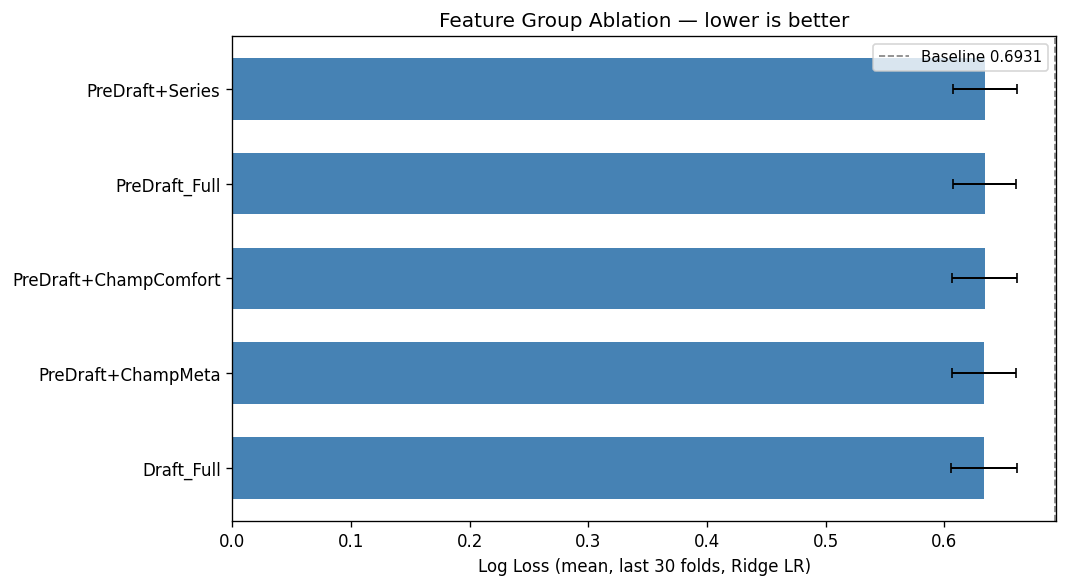

In [26]:
# ── Ablation chart ──────────────────────────────────────────────────────────
if abl_df is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    abl_sorted = abl_df.sort_values('mean_logloss')
    bars = ax.barh(
        abl_sorted['ablation'], abl_sorted['mean_logloss'],
        xerr=abl_sorted['std_logloss'], color='steelblue', height=0.65,
        error_kw={'capsize': 3, 'elinewidth': 1.2},
    )
    ax.axvline(BASELINE_METRICS['log_loss'], color='gray', ls='--', lw=1, label=f'Baseline {BASELINE_METRICS["log_loss"]:.4f}')
    ax.set_xlabel('Log Loss (mean, last 30 folds, Ridge LR)')
    ax.set_title('Feature Group Ablation — lower is better')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'ablation_chart.png', dpi=150)
    plt.show()

### 10b. Targeted comparisons: style features and interactions

These answer the two key questions from the analysis:
1. Do style features (Group F) add signal or hurt generalisation?
2. Do explicit interaction terms add signal beyond the base features?

In [27]:
from pipeline.evaluation import ABLATION_GROUPS, ABLATION_SETS
from pipeline.models import train_eval_fold, make_preprocessor, BASELINE_METRICS
from sklearn.base import clone
import numpy as np

def run_targeted_comparison(label_a, cols_a, label_b, cols_b,
                            model_name='ridge_lr', n_folds=20):
    """Compare two feature sets on the last n_folds, return summary."""
    test_folds = folds[-n_folds:]
    results = {label_a: [], label_b: []}

    for cols, label in [(cols_a, label_a), (cols_b, label_b)]:
        num_c = [c for c in cols if c in num_cols]
        cat_c = [c for c in cat_cols if c in ds_df.columns]
        for tr_idx, val_idx in test_folds:
            tr  = dev_df.loc[tr_idx]
            val = dev_df.loc[val_idx]
            pre = make_preprocessor(num_c, cat_c)
            X_tr  = pre.fit_transform(tr[num_c + cat_c])
            X_val = pre.transform(val[num_c + cat_c])
            m = train_eval_fold(model_name, X_tr, tr['result'].values,
                                X_val, val['result'].values)
            results[label].append(m['log_loss'])

    for label, losses in results.items():
        print(f'{label:40s}  logloss={np.mean(losses):.5f} ± {np.std(losses):.5f}')
    delta = np.mean(results[label_b]) - np.mean(results[label_a])
    print(f'  Δ ({label_b} vs {label_a}): {delta:+.5f}  (negative = B is better)')
    return results


# ── Test 1: with vs without style features (Group F) ───────────────────────
style_feat_names = ['pace_mean_L10', 'vision_mean_L10', 'economy_mean_L10',
                    'aggression_mean_L10', 'gamelength_mean_L10']

# Build both col sets (include opp_ and diff_ versions automatically)
no_style  = [c for c in num_cols if not any(s in c for s in style_feat_names)]
with_style = num_cols  # current full set

print('=== Style Features (Group F) ===')
run_targeted_comparison('without_style', no_style, 'with_style', with_style)

=== Style Features (Group F) ===
without_style                             logloss=0.63850 ± 0.03497
with_style                                logloss=0.63621 ± 0.03362
  Δ (with_style vs without_style): -0.00229  (negative = B is better)


{'without_style': [0.710670732502717,
  0.6499801714574048,
  0.6630690383656639,
  0.6398347259138347,
  0.6296151031686451,
  0.6092854002830109,
  0.6283495563609708,
  0.6781442662762273,
  0.6541880762546267,
  0.6668776498548519,
  0.6468307614146755,
  0.6451795654963866,
  0.5972337002989175,
  0.5652798484861903,
  0.5670009079525192,
  0.6115913830104074,
  0.6437705928270079,
  0.6294269086596662,
  0.6590463883136373,
  0.6746264383096202],
 'with_style': [0.7012230089445617,
  0.6425706812875971,
  0.6514011570114491,
  0.629928485329783,
  0.6197386345808247,
  0.6070718101535949,
  0.6310572904735295,
  0.6777315430315746,
  0.6454702879876483,
  0.6690106561947132,
  0.6468371872978267,
  0.6517062983052947,
  0.5981944205906335,
  0.5653792028581484,
  0.5698157097909602,
  0.6117628887348475,
  0.6453055506895573,
  0.628900319564296,
  0.65225546919124,
  0.6788716737146372]}

In [28]:
# ── Test 2: with vs without interaction features (Group K) ──────────────────
no_interact   = [c for c in num_cols if not c.startswith('ix_')]
with_interact = num_cols

print('=== Interaction Features (Group K) ===')
run_targeted_comparison('without_interactions', no_interact, 'with_interactions', with_interact)

print()
# ── Test 3: with vs without threshold features (C_thresholds) ───────────────
thresh_names = ['pct_gdiff15_gt', 'pct_gdiff15_lt', 'pct_gdiff10_gt', 'pct_gdiff10_lt']
no_thresh   = [c for c in num_cols if not any(c.startswith(t) or 
                                               c.replace('opp_','').replace('diff_','').startswith(t)
                                               for t in thresh_names)]
with_thresh = num_cols

print('=== Threshold Features (C_thresholds) ===')
run_targeted_comparison('without_thresholds', no_thresh, 'with_thresholds', with_thresh)

print()
# ── Test 4: with vs without decayed Elo ─────────────────────────────────────
dec_elo_names = ['elo_decayed_team', 'elo_decayed_opp', 'elo_decayed_diff', 'ix_dec_elo']
no_dec_elo   = [c for c in num_cols if not any(c.startswith(d) for d in dec_elo_names)]
with_dec_elo = num_cols

print('=== Decayed Elo ===')
run_targeted_comparison('without_decayed_elo', no_dec_elo, 'with_decayed_elo', with_dec_elo)

=== Interaction Features (Group K) ===
without_interactions                      logloss=0.63698 ± 0.03478
with_interactions                         logloss=0.63621 ± 0.03362
  Δ (with_interactions vs without_interactions): -0.00077  (negative = B is better)

=== Threshold Features (C_thresholds) ===
without_thresholds                        logloss=0.63682 ± 0.03584
with_thresholds                           logloss=0.63621 ± 0.03362
  Δ (with_thresholds vs without_thresholds): -0.00061  (negative = B is better)

=== Decayed Elo ===
without_decayed_elo                       logloss=0.63692 ± 0.03508
with_decayed_elo                          logloss=0.63621 ± 0.03362
  Δ (with_decayed_elo vs without_decayed_elo): -0.00071  (negative = B is better)


{'without_decayed_elo': [0.715627845126821,
  0.6456595156910758,
  0.651296482424933,
  0.6288874144960821,
  0.620795385101229,
  0.607429670311634,
  0.6307393161953422,
  0.6769368893120904,
  0.6458204302027776,
  0.6698465388588007,
  0.647549495588753,
  0.6465587284000568,
  0.5983972835631733,
  0.5651984604453739,
  0.5697653930292288,
  0.6120182049155487,
  0.6451302545960496,
  0.628963682290985,
  0.6522618667574694,
  0.6794762395477959],
 'with_decayed_elo': [0.7012230089445617,
  0.6425706812875971,
  0.6514011570114491,
  0.629928485329783,
  0.6197386345808247,
  0.6070718101535949,
  0.6310572904735295,
  0.6777315430315746,
  0.6454702879876483,
  0.6690106561947132,
  0.6468371872978267,
  0.6517062983052947,
  0.5981944205906335,
  0.5653792028581484,
  0.5698157097909602,
  0.6117628887348475,
  0.6453055506895573,
  0.628900319564296,
  0.65225546919124,
  0.6788716737146372]}

---
## 11. Leakage Checklist

In [29]:
from pipeline.evaluation import leakage_report
leakage_report(ds_df, num_cols)

20:32:02  INFO     ============================================================
20:32:02  INFO     LEAKAGE CHECKLIST
20:32:02  INFO     ============================================================
20:32:02  INFO       [FAIL]  No draft columns  |  ['has_first_pick', 'opp_has_first_pick', 'diff_has_first_pick']
20:32:02  INFO       [PASS]  No same-match realised stats  |  OK
20:32:02  INFO       [PASS]  No raw at-time snapshots  |  OK
20:32:02  INFO       [PASS]  opp_ features are rolling (not same-match)  |  OK – built in dataset.py
20:32:02  INFO       [PASS]  gamelength not used as direct feature  |  OK – only gamelength_mean_L10 (lagged)
20:32:02  INFO     ============================================================
20:32:02  ERROR    LEAKAGE CHECK FAILURES DETECTED – review above.


In [30]:
# Manual spot-checks
# Pick a random team and verify their features at a given match are consistent
# with a manual calculation from their prior match history

import random
random.seed(42)

team_name = 'T1'   # change to any team
team_rows = ds_df[ds_df['teamname'] == team_name].sort_values('date')

if team_rows.empty:
    print(f'{team_name} not found. Available teams (sample):', ds_df['teamname'].dropna().unique()[:10].tolist())
else:
    # Pick the 20th match (enough history to check rolling features)
    idx = min(20, len(team_rows) - 1)
    row = team_rows.iloc[idx]
    prior = team_rows.iloc[:idx]

    print(f'Team: {team_name}')
    print(f'Match date: {row["date"].date()}')
    print(f'Prior matches used: {len(prior)}')
    print()

    # Manual check: wr_L5
    manual_wr5 = prior['result'].tail(5).mean()
    print(f'wr_L5  — pipeline: {row["wr_L5"]:.4f}  manual: {manual_wr5:.4f}  match: {abs(row["wr_L5"] - manual_wr5) < 0.001}')

    # Manual check: gdiff15_mean_L10 (may be 0 for early matches with no data)
    if 'gdiff15_mean_L5' in ds_df.columns:
        # Can't recompute here (raw data dropped), but we can verify range is sensible
        print(f'gdiff15_mean_L5 — pipeline: {row.get("gdiff15_mean_L5", "N/A")}  (sensible range: -3000 to 3000)')

    # Elo should be > 1500 if this team is good
    print(f'elo_team — {row["elo_team"]:.1f}')

KeyError: 'teamname'

---
## 12. Output Files

All outputs are saved to `./outputs/`:

In [ ]:
print('Output files:')
for p in sorted(OUTPUT_DIR.iterdir()):
    size = p.stat().st_size
    print(f'  {p.name:<35}  {size/1024:.1f} KB')